<a href="https://colab.research.google.com/github/tanishataranoon/Evalution_toxic_Text/blob/main/Toxic_text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Toxic Comment Classification:
# A Comparative Study of ML, DL, and Transformer Models

# Course: CSE 414 - ML & DL Lab


# 1. Install & import

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [ ]:
# Core
import numpy as np
import pandas as pd
import re
import time
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import *

# DL
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

# Transformer
import torch
from transformers import *

sns.set_theme(style='whitegrid')

# 2. Dataset Loading

from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


## 2.1 Load dataset


In [ ]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

README.md:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

train.csv: reconstructing file:   0%|          |  0.00B / 68.8MB            

train.csv: downloading bytes:           |  0.00B            

test.csv: reconstructing file:   0%|          |  0.00B / 60.4MB            

test.csv: downloading bytes:           |  0.00B            

test_labels.csv:   0%|          | 0.00/4.98M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

## 2.2 Basic inspection

In [ ]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [ ]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()
print(train_df.shape)
print(test_df.shape)

(159571, 8)
(306328, 8)


## 2.3 Label setup & Toxic distribution

In [ ]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [ ]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [ ]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


# 3 . Exploratory Data Analysis (EDA)


## 3.1 Label distribution

In [ ]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


In [ ]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


## 3.2 Toxic vs non-toxic

Bar Chart of Number of Comments per Toxicity Label
A pie chart for non-toxic vs toxic

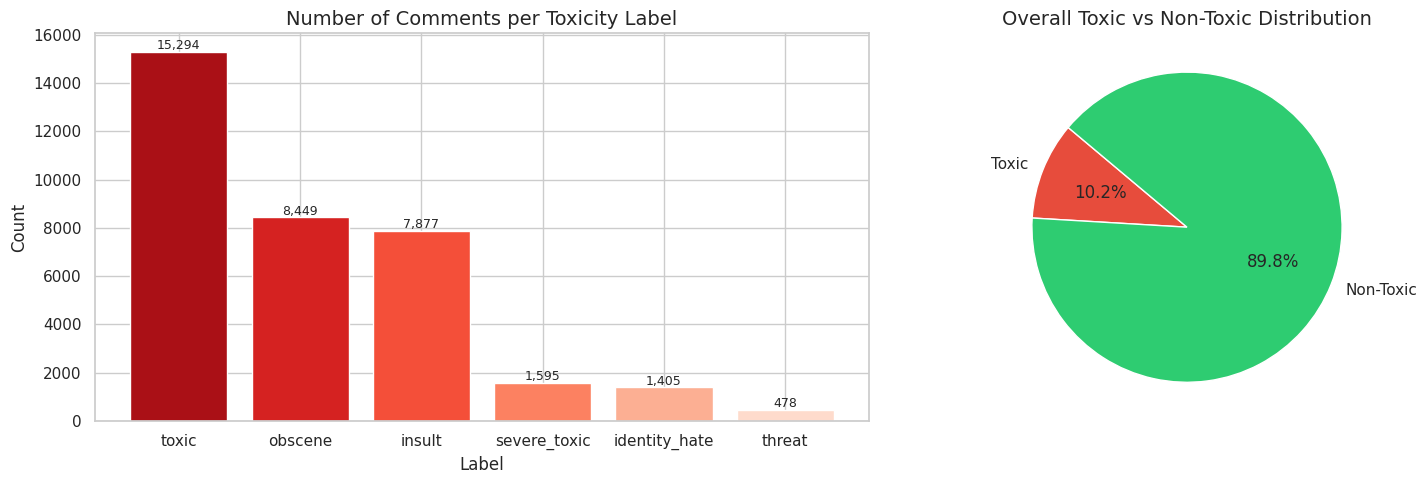

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3 Co-occurrence heatmap

Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

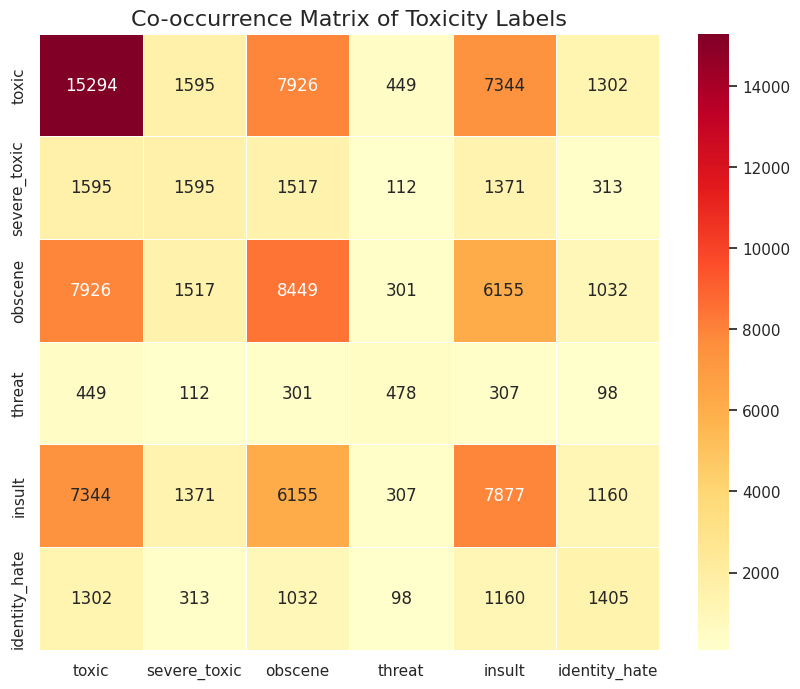

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.4 Word clouds

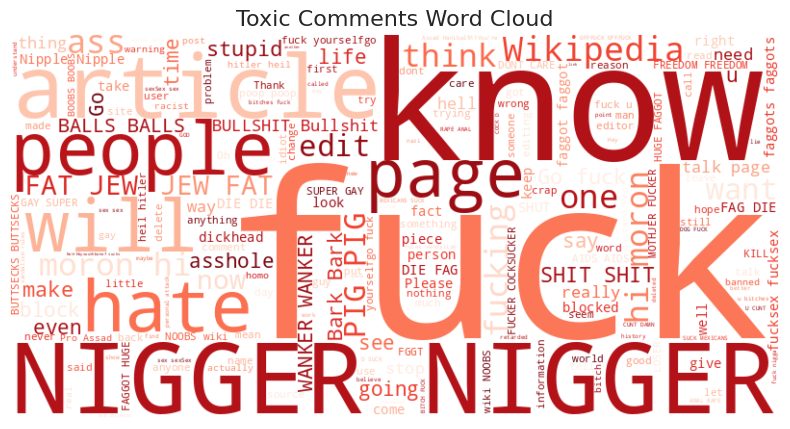

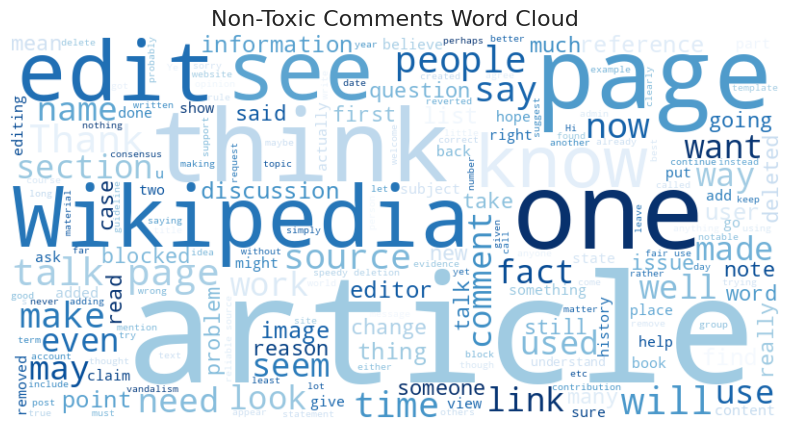

In [ ]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

## 3.5 Top n-grams

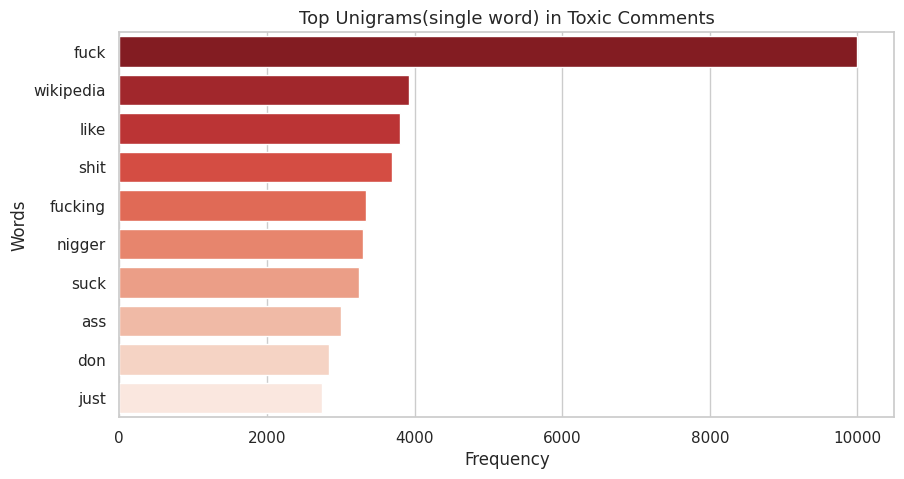

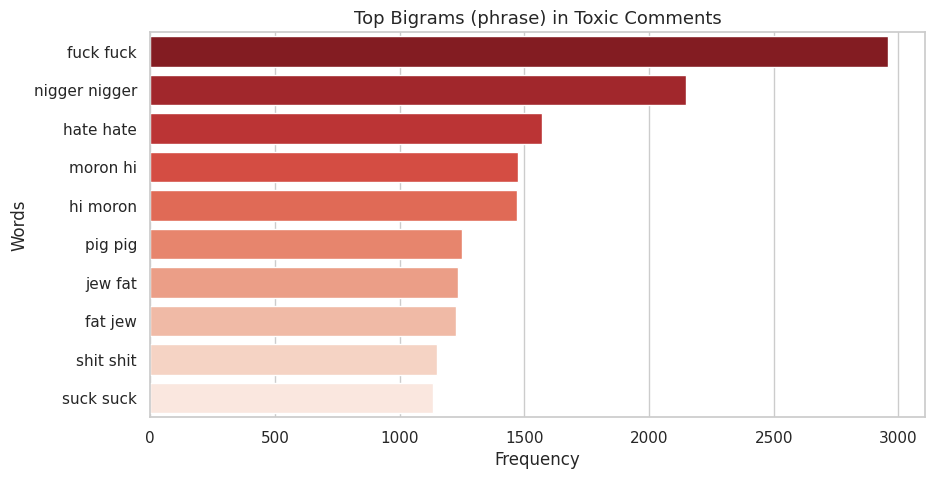

In [ ]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# 4. Preprocessing

## 4.1 Basic preprocessing



1.  Lower case



In [ ]:
def to_lower(text):
    return text.lower()




2. URL remove



In [ ]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)

3. Mentions remove




In [ ]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)

4. Remove Punctuation

In [ ]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)

5. Remove extra space

In [ ]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

## 4.2 Advance Preprocessing

1. Emoji to text

In [ ]:
!pip install emoji
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.4 MB/s eta 0:00:00


2. Convert to full forms

In [ ]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [ ]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4.Bad Word Normalization \
b!tch = bitch

In [ ]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [ ]:
def tokenize_text(text):
    return word_tokenize(text)

6. Stopwords

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

7. Lemmatize

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

## 4.3 Final pipelines



1.   Basic Preprocess Function



In [ ]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text



2.  Advanced Preprocess Function



In [ ]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# 5. Apply Preprocessing



## 1. Applying Basic Preprocess Function






In [ ]:
train_df["raw"] = train_df["comment_text"]
train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)

Comparison Of Raw and Basic Clean by Basic Preprocessing

In [ ]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
128750,"I have requested assistance at the administrator's noticeboard, as I'm afraid that the material that may need investigation is more extensive than I can easily handle on my own. You can see my request here, and you are, of course, welcome to contribute to that thread. Please note that I have not accused you there of intentionally violating copyright, as I do not believe you are acting from bad faith, but perhaps from a misunderstanding of our policies and copyright law. I would be very happy to talk with you to clarify how material can be best revised if the links I've already given you are unclear. (talk)",i have requested assistance at the administrators noticeboard as im afraid that the material that may need investigation is more extensive than i can easily handle on my own you can see my request here and you are of course welcome to contribute to that thread please note that i have not accused you there of intentionally violating copyright as i do not believe you are acting from bad faith but perhaps from a misunderstanding of our policies and copyright law i would be very happy to talk with you to clarify how material can be best revised if the links ive already given you are unclear talk
26750,"Fuck off, you half-wit\nYou wikiwankers set the standard for delusional.",fuck off you halfwit you wikiwankers set the standard for delusional
146527,"""\n\n Talk:Alien (creature in Alien franchise)‎ \n\nWould greatly appreciate your input at Talk:Alien (creature in Alien franchise)‎#Images, if you have a few minutes to express your opinion on the matter. Thanks! X """,talkalien creature in alien franchise would greatly appreciate your input at talkalien creature in alien franchiseimages if you have a few minutes to express your opinion on the matter thanks x
118600,Was this page started by some CIA paid propaganda agent? 81.159.82.167,was this page started by some cia paid propaganda agent
4603,fucking liberal prick and get a life!,fucking liberal prick and get a life


## 2. Applying Advanced Preprocess Function

In [ ]:
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)

Comparison of Raw and Advanced Clean by Advanced Preprocessing

In [ ]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
106079,"""\n\n Same-sex marriage in the United States \n\nI've undone your revert on the intro to this article, because although it's in good faith, I think it's mistaken. The reason you gave was that the information is elsewhere in the article, which is already long, so the intro shouldn't cover it even in summary, as it's in the main body under """"History"""". Although I respect your intent of keeping it concise and avoiding redundancy, the Manual of Style for the intro is quite clear:\n The lead serves as an introduction to the article and a summary of its most important aspects ... [It] should be able to stand alone as a concise overview. It should define the topic, establish context, explain why the topic is notable, and summarize the most important points, including any prominent controversies ... The lead is the first part of the article most people read, and many only read the lead.\n\nThe issue here is that the intro currently says that state bans were declared unlawful in 2015, 38+ states provided some rights as from 2003, and Windsor gave federal rights in 2013. There needs to be some mention of the backdrop and prior controversies as they were huge, and an increase from 2 to 3 paras to add substance on the background + context is (in my view) appropriate: even very long articles still need a proper introduction that summarizes their contents. Take a look at African-American Civil Rights Movement (1954–68) for an example of the intro to a long-ish article. \n\nIf you disagree with my reasons, maybe we can take it to the talk page and raise it there/see what others say first, before re-reverting. FT2 (Talk | email) """,samesex marriage united state ive undone revert intro article although good faith think mistaken reason gave information elsewhere article already long intro shouldnt cover even summary main body history although respect intent keeping concise avoiding redundancy manual style intro quite clear lead serf introduction article summary important aspect able stand alone concise overview define topic establish context explain topic notable summarize important point including prominent controversy lead first part article people read many read lead issue intro currently say state ban declared unlawful state provided right windsor gave federal right need mention backdrop prior controversy huge increase para add substance background context view appropriate even long article still need proper introduction summarizes content take look africanamerican civil right movement example intro longish article disagree reason maybe take talk page raise theresee others say first rereverting ft talk email
141112,The Federal Police is on to you! \n\nYou racist anti-Australian! I WILL get the Federal Police on you to put you in prison! AUSSIE PRIDE!58.178.146.217,federal police racist antiaustralian get federal police put prison aussie pride
139934,"""\n\nFootnotes\nI guess (and it is only a guess) that """"Notes"""" arose as a section title because, strictly speaking, they do not appear at the foot of the page. (Talk) """,footnote guess guess note arose section title strictly speaking appear foot page talk
122964,"Agreed, and the current revision is acceptable.",agreed current revision acceptable
2929,"Convoy template\n\nDoes this cover it? \nFor the main template I've put items that ought to be there; some have pages, some don't.\nFor the other sections I've put in the items with pages that already exist.\nI don't know yet what the bwst arrangement is.",convoy template cover main template ive put item ought page section ive put item page already exist know yet bwst arrangement


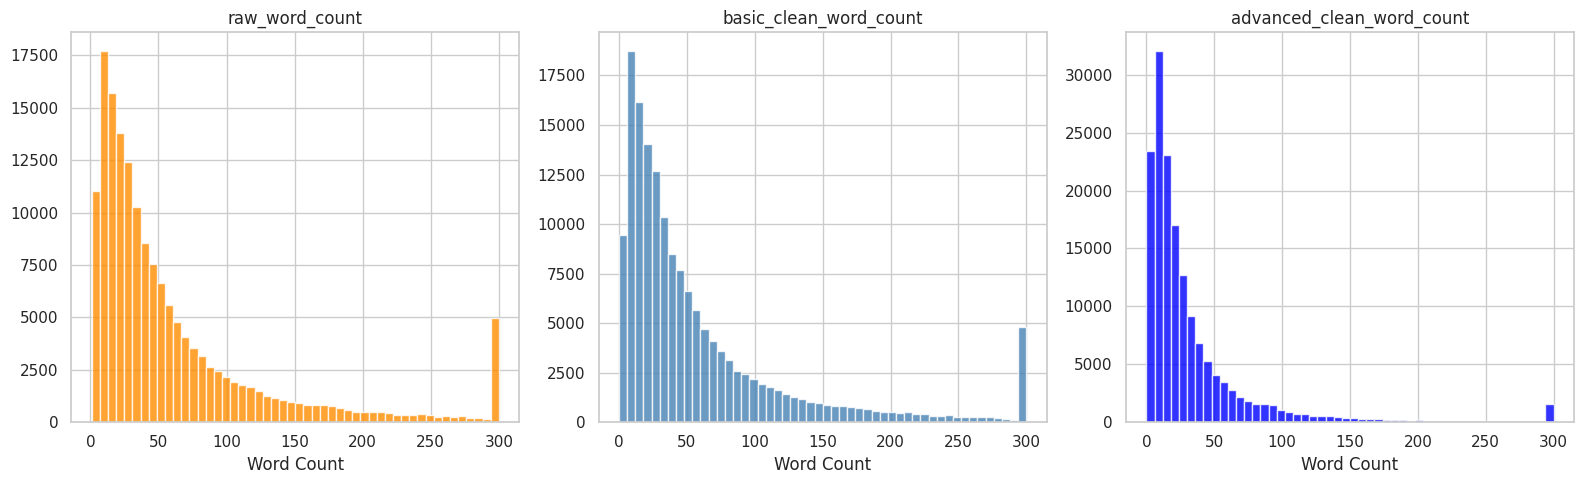

In [ ]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


# 6. Train/Validation/Test Split

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')


Train : 127,656  |  Val : 15,957  |  Test : 15,958


# 7. Feature Extraction

## 7.1 TF-IDF Features

(for LR and SVM)
use advanced_clean

In [ ]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])

In [ ]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


## 7.2 LSTM Tokenization

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
Vocab_size =10000
max_len= 100

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['advanced_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts)
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['advanced_clean'])
X_val_lstm = to_padded(X_val['advanced_clean'])
X_test_lstm = to_padded(X_test['advanced_clean'])

## 7.3 BERT Tokenization

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

In [ ]:
MODEL_NAME = "distilbert-base-uncased"

Bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
def bert_encode(texts, max_len=512):
   enc =bert_tokenizer(
       list(texts),
       max_length=max_len,
       truncation=True,
       padding = 'max_length',
       return_tensors='pt'
   )
   return enc['input_ids'], enc['attention_mask']

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

[transformers] loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--distilbert-base-uncased/snapshots/12040accade4e8a0f71eabdb258fecc2e7e948be/config.json
[transformers] Model config DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "eos_token_id": null,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.13.1",
  "vocab_size": 30522
}



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

# 8 . Evaluation Utilities

## 1. evaluate()

In [ ]:
results ={}
def evaluate(model_name,y_true,y_pred, elapsed_train=None,elapsed_infer=None ):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro',zero_division=0)
  rec = recall_score(y_true, y_pred, average='macro',zero_division=0)
  f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)

  results[model_name] = {
      'accuracy': round(acc,4),
      'precision': round(prec,4),
      'recall': round(rec,4),
      'f1 (macro)': round(f1,4),
      'train time (s)':round( elapsed_train,1) if elapsed_train else '-',
      'infer time (s)': round(elapsed_infer,1) if elapsed_infer else '-'
  }
  print(f'\n===== {model_name} =====')
  print(f'  accuracy : {acc:.4f}')
  print(f'  precision: {prec:.4f}')
  print(f'  recall   : {rec:.4f}')
  print(f'  f1 Macro : {f1:.4f}')
  if elapsed_train: print(f'  train time: {elapsed_train:.1f}s')
  return results[model_name]

## 2. confusion matrix

In [ ]:
def plot_confusion(model_name,y_true, y_pred, lables=label_cols):
   fig, axes = plt.subplots( 2,3, figsize=(15,8))
   for ax, col in zip(axes.flatten(), lables):
       cm = confusion_matrix(y_true[:, lables.index(col)],
                              y_pred[:, lables.index(col)])
       sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', cbar=False)
       ax.set_title(col, fontsize=11)
       ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
   plt.suptitle(f'Confusion Matrices — {model_name}', fontsize=14)
   plt.tight_layout()
   plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
   plt.show()

print('Evaluation helpers ready.')

Evaluation helpers ready.


# 9. Traditional ML Models

## 9.1 Logistic Regression

Raw Text

In [ ]:
tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_raw = tfidf_raw.fit_transform(X_train['raw'])
X_test_tfidf_raw = tfidf_raw.transform(X_test['raw'])

lr_raw = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_raw.fit(X_train_tfidf_raw, y_train)
with open('lr_raw_model.pkl', 'wb') as f:
    pickle.dump(lr_raw, f)
with open('tfidf_raw_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_raw, f)

In [ ]:
with open('tfidf_raw_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)
with open('lr_raw_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [ ]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')
t0=time.time()
y_pred_raw = lr_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 18.2s


Evaluate the model for raw data

In [ ]:
evaluate('TF-IDF + LR (raw)', y_test.values, y_pred_raw, train_t, infer_t)


===== TF-IDF + LR (raw) =====
  accuracy : 0.9204
  precision: 0.8366
  recall   : 0.3936
  f1 Macro : 0.5099
  train time: 18.2s


{'accuracy': 0.9204,
 'precision': 0.8366,
 'recall': 0.3936,
 'f1 (macro)': 0.5099,
 'train time (s)': 18.2,
 'infer time (s)': 0.0}

Confusion plot for the model for raw data

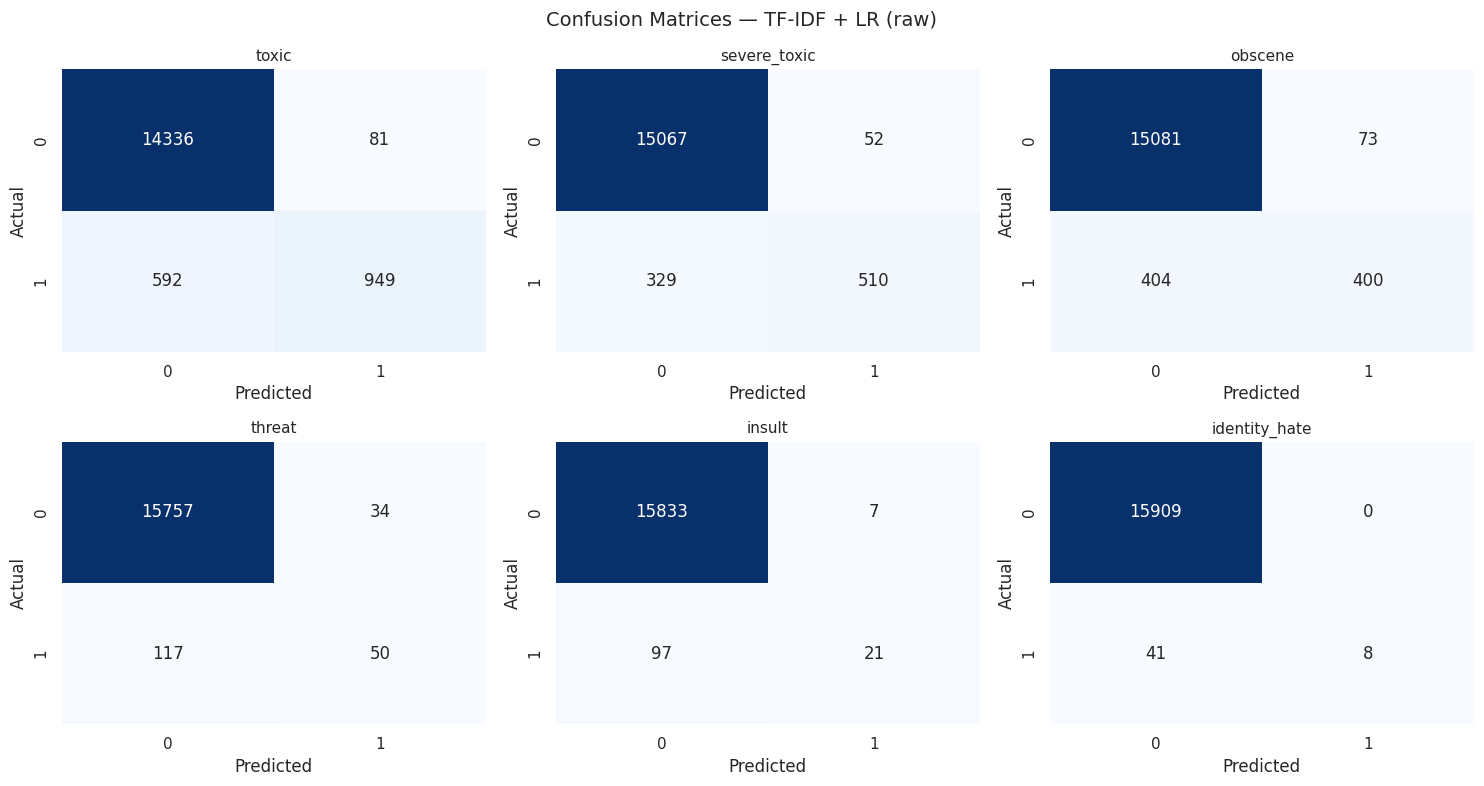

In [ ]:
plot_confusion('TF-IDF + LR (raw)', y_test.values, y_pred_raw, label_cols)

Advanced Clean

In [ ]:
tfidf_clean = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_clean = tfidf_clean.fit_transform(X_train['advanced_clean'])
X_test_tfidf_clean = tfidf_clean.transform(X_test['advanced_clean'])

lr_clean = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_clean.fit(X_train_tfidf_clean, y_train)
with open('lr_clean_model.pkl', 'wb') as f:
    pickle.dump(lr_clean, f)
with open('tfidf_clean_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_clean, f)

In [ ]:
with open('tfidf_clean_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)
with open('lr_clean_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [ ]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')
t0=time.time()
y_pred_clean = lr_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 11.7s


Evaluate the model for clean data

In [ ]:
evaluate('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, train_t, infer_t)


===== TF-IDF + LR (advanced) =====
  accuracy : 0.9189
  precision: 0.7585
  recall   : 0.3845
  f1 Macro : 0.4852
  train time: 11.7s


{'accuracy': 0.9189,
 'precision': 0.7585,
 'recall': 0.3845,
 'f1 (macro)': 0.4852,
 'train time (s)': 11.7,
 'infer time (s)': 0.0}

Confusion plot for the model for clean data

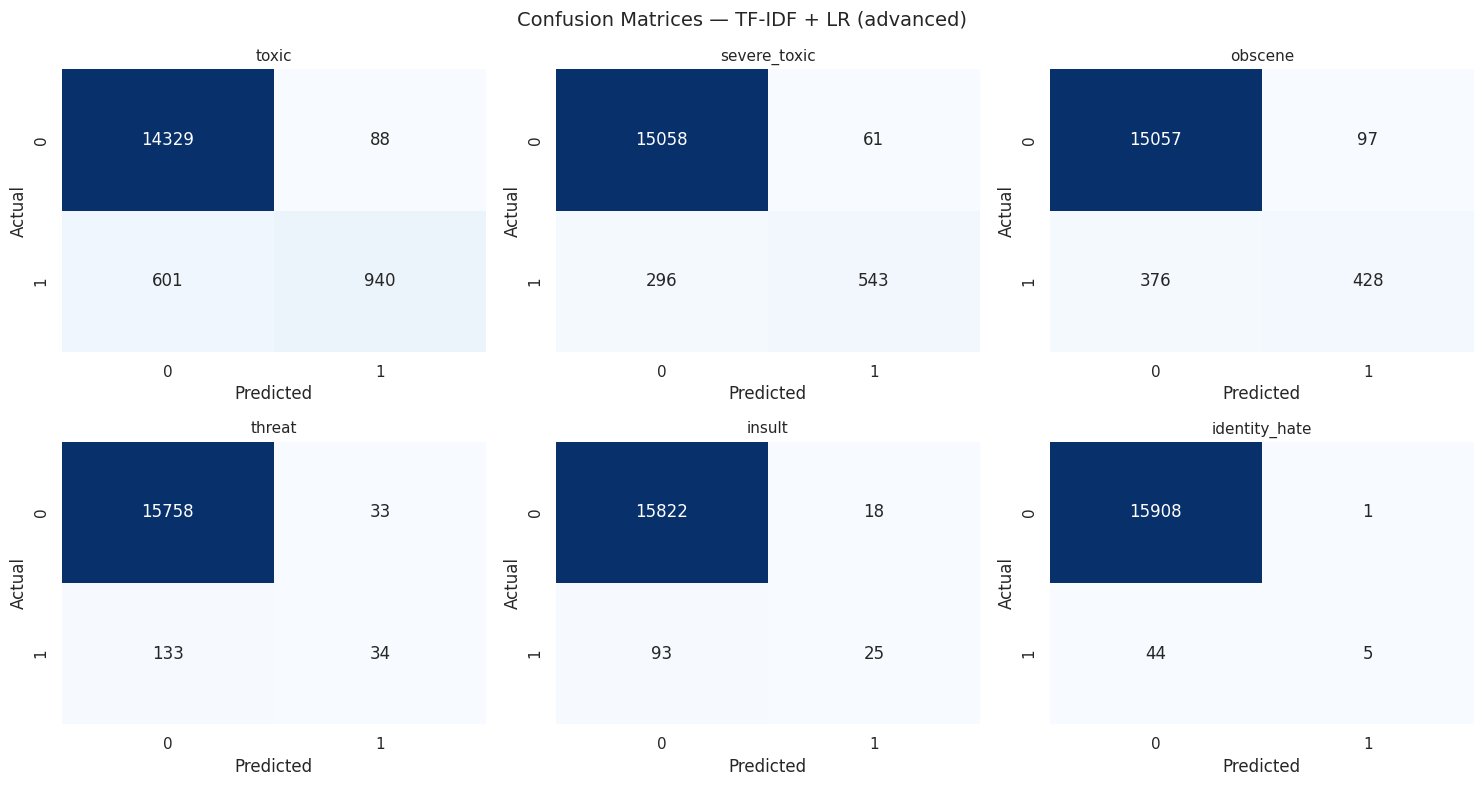

In [ ]:
plot_confusion('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, label_cols)

## 9.2 SVM

Raw Text

In [ ]:
svm_raw = OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_raw.fit(X_train_tfidf_raw, y_train)
with open('svm_raw_model.pkl', 'wb') as f:
    pickle.dump(svm_raw, f)

In [ ]:
with open('svm_raw_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [ ]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')
t0=time.time()
y_pred_svm_raw = svm_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 13.4s


Evaluate the model for raw data

In [ ]:
evaluate('TF-IDF + SVM (raw)', y_test.values, y_pred_svm_raw, train_t, infer_t)


===== TF-IDF + SVM (raw) =====
  accuracy : 0.9209
  precision: 0.7476
  recall   : 0.5065
  f1 Macro : 0.5944
  train time: 13.4s


{'accuracy': 0.9209,
 'precision': 0.7476,
 'recall': 0.5065,
 'f1 (macro)': 0.5944,
 'train time (s)': 13.4,
 'infer time (s)': 0.0}

Confusion plot for the model for raw data

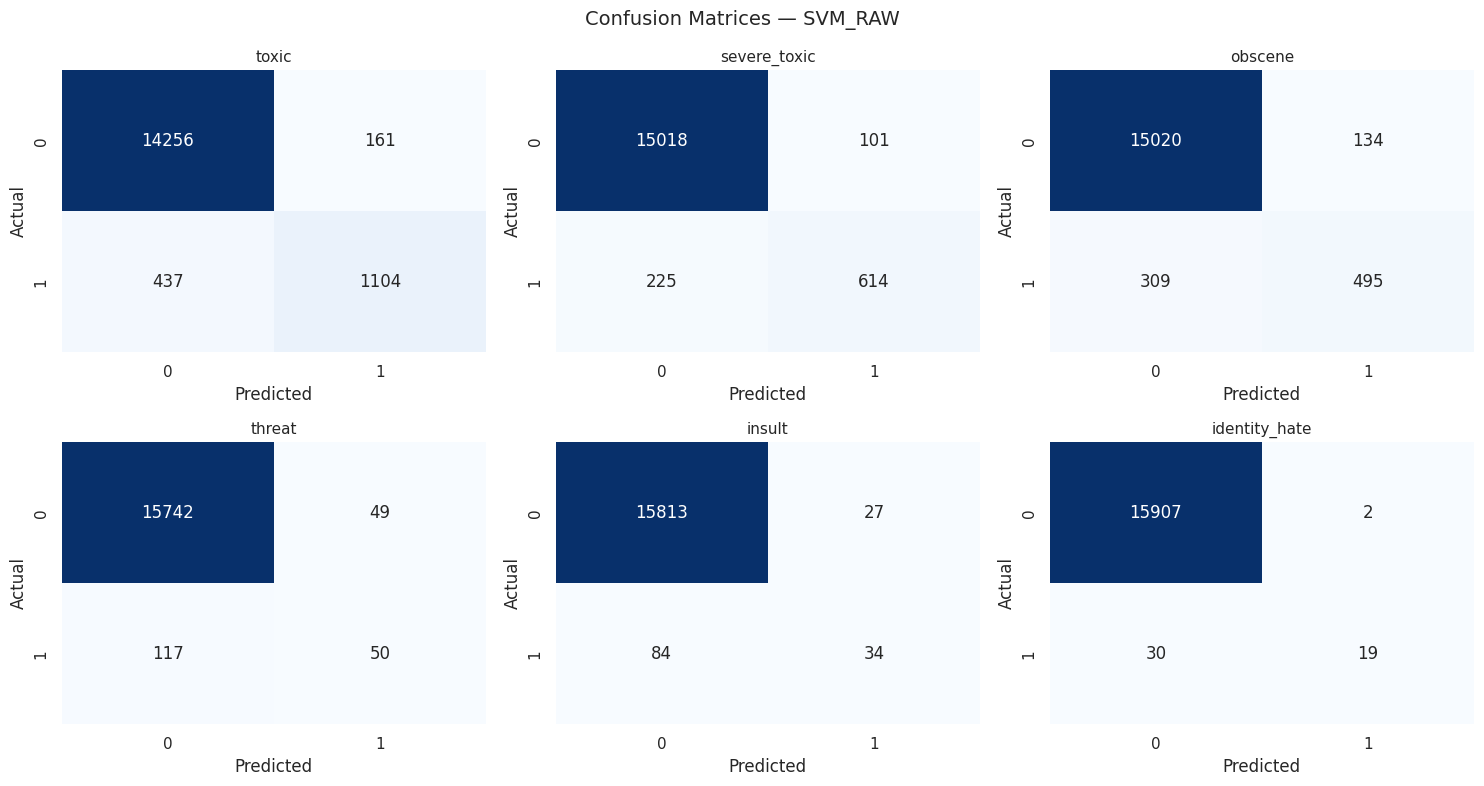

In [ ]:
plot_confusion('SVM_RAW',y_test.values,y_pred_svm_raw,label_cols)

Advanced Clean

In [ ]:
svm_clean= OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_clean.fit(X_train_tfidf_clean, y_train)
with open('svm_clean_model.pkl', 'wb') as f:
    pickle.dump(svm_clean, f)

In [ ]:
with open('svm_clean_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [ ]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_clean = svm_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 7.0s



Evaluate the model for clean data

In [ ]:
evaluate('TF-IDF + SVM (advanced)', y_test.values, y_pred_svm_clean, train_t, infer_t)


===== TF-IDF + SVM (advanced) =====
  accuracy : 0.9187
  precision: 0.7193
  recall   : 0.4957
  f1 Macro : 0.5780
  train time: 7.0s


{'accuracy': 0.9187,
 'precision': 0.7193,
 'recall': 0.4957,
 'f1 (macro)': 0.578,
 'train time (s)': 7.0,
 'infer time (s)': 0.0}

Confusion plot for the model for clean data

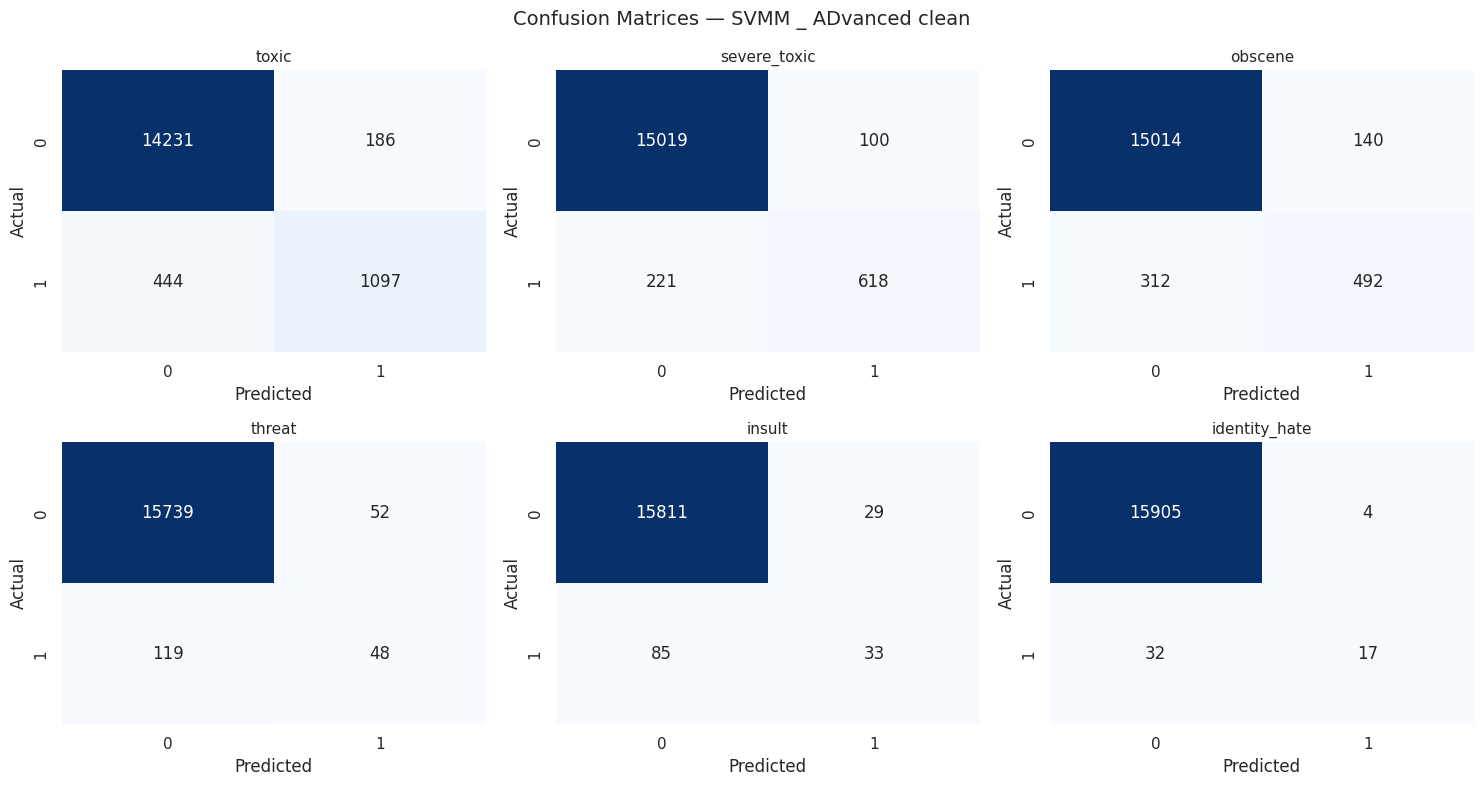

In [ ]:
plot_confusion("SVMM _ ADvanced clean", y_test.values, y_pred_svm_clean, label_cols)

# 10. Deep Learning Model

## 10.1 BiLSTM — Basic Clean

Building the model

In [ ]:
EMBED_DIM = 128
NUM_LABELS = len(label_cols)

def build_bilstm(Vocab_size, max_len, num_labels):
    inp  = Input(shape=(max_len,))
    x    = Embedding(Vocab_size, EMBED_DIM)(inp)
    x    = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2))(x)
    x    = GlobalMaxPooling1D()(x)
    x    = Dense(128, activation='relu')(x)
    x    = Dropout(0.3)(x)
    out  = Dense(num_labels, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model
lstm_model = build_bilstm(Vocab_size , max_len, NUM_LABELS)
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,396,102 (5.33 MB)

 Trainable params: 1,396,102 (5.33 MB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Advanced clean

In [ ]:
callbacks =[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
            ]
t0=time.time()
history = lstm_model.fit(
    X_train_lstm, y_train.values,
    validation_data=(X_val_lstm, y_val.values),
    epochs=10,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)
lstm_model.save("bilstm_model.h5")

Epoch 1/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.8792 - loss: 0.0777 - val_accuracy: 0.9927 - val_loss: 0.0510 - learning_rate: 0.0010
Epoch 2/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9724 - loss: 0.0491 - val_accuracy: 0.9927 - val_loss: 0.0507 - learning_rate: 0.0010
Epoch 3/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9740 - loss: 0.0447 - val_accuracy: 0.9927 - val_loss: 0.0506 - learning_rate: 0.0010
Epoch 4/10
995/998 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9708 - loss: 0.0419
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
998/998 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.9603 - loss: 0.0405 - val_accuracy: 0.9927 - val_loss: 0.0525 - learning_rate: 0.0010
Epoch 5/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.9424 - loss: 0.0351 - val_accuracy: 0.9925 - val_loss: 0.0558 - learning_rate: 5.0000e-04
Epoch 6/10
996/998 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9364 - 

In [ ]:
from tensorflow.keras.models import load_model
loaded_lstm = load_model("bilstm_model.h5")

In [ ]:
train_t = time.time() - t0

print(f'Train time: {train_t:.1f}s')
t0 = time.time()
y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype(int)
lstm_infer_t = time.time() - t0

Train time: 122.5s
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


In [ ]:
evaluate('LSTM — advanced_clean', y_test.values, y_pred_lstm,
         train_t, lstm_infer_t)


===== LSTM — advanced_clean =====
  accuracy : 0.9163
  precision: 0.4806
  recall   : 0.4353
  f1 Macro : 0.4533
  train time: 122.5s


{'accuracy': 0.9163,
 'precision': 0.4806,
 'recall': 0.4353,
 'f1 (macro)': 0.4533,
 'train time (s)': 122.5,
 'infer time (s)': 5.2}

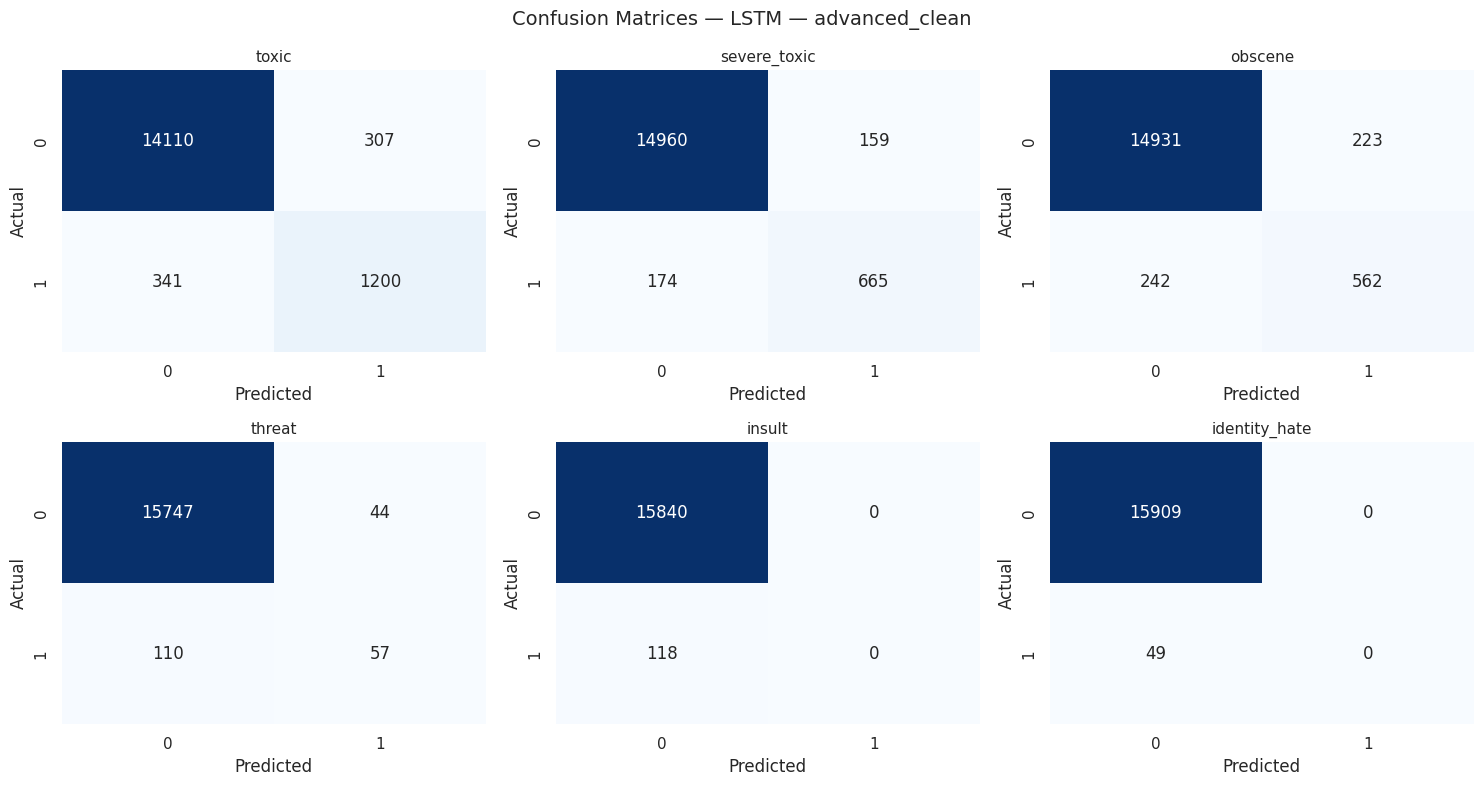

In [ ]:
plot_confusion('LSTM — advanced_clean', y_test.values, y_pred_lstm,label_cols)

## Raw DATA

In [ ]:
lstm_tok_raw = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok_raw.fit_on_texts(X_train['raw'])

def to_padded_raw(texts):
    seqs = lstm_tok_raw.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen= max_len ,padding='post', truncating='post')

X_train_lstm_raw = to_padded_raw(X_train['raw'])
X_val_lstm_raw   = to_padded_raw(X_val['raw'])
X_test_lstm_raw  = to_padded_raw(X_test['raw'])

lstm_raw_model = build_bilstm(Vocab_size, max_len, NUM_LABELS)

t0 = time.time()
lstm_raw_model.fit(
    X_train_lstm_raw, y_train.values,
    validation_data=(X_val_lstm_raw, y_val.values),
    epochs=10, batch_size=256,
    callbacks=callbacks, verbose=1
)
lstm_raw_model.save("lstm_raw_model.h5")

In [ ]:
loaded_lstm = load_model("lstm_raw_model.h5")

In [ ]:
lstm_raw_train_time = time.time() - t0

t0 = time.time()
y_pred_lstm_raw = (lstm_raw_model.predict(X_test_lstm_raw) > 0.5).astype(int)
lstm_raw_infer = time.time() - t0

499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


In [ ]:
evaluate('LSTM — Raw', y_test.values, y_pred_lstm_raw, lstm_raw_train_time, lstm_raw_infer)


===== LSTM — Raw =====
  accuracy : 0.9181
  precision: 0.4855
  recall   : 0.4211
  f1 Macro : 0.4427
  train time: 60.5s


{'accuracy': 0.9181,
 'precision': 0.4855,
 'recall': 0.4211,
 'f1 (macro)': 0.4427,
 'train time (s)': 60.5,
 'infer time (s)': 5.2}

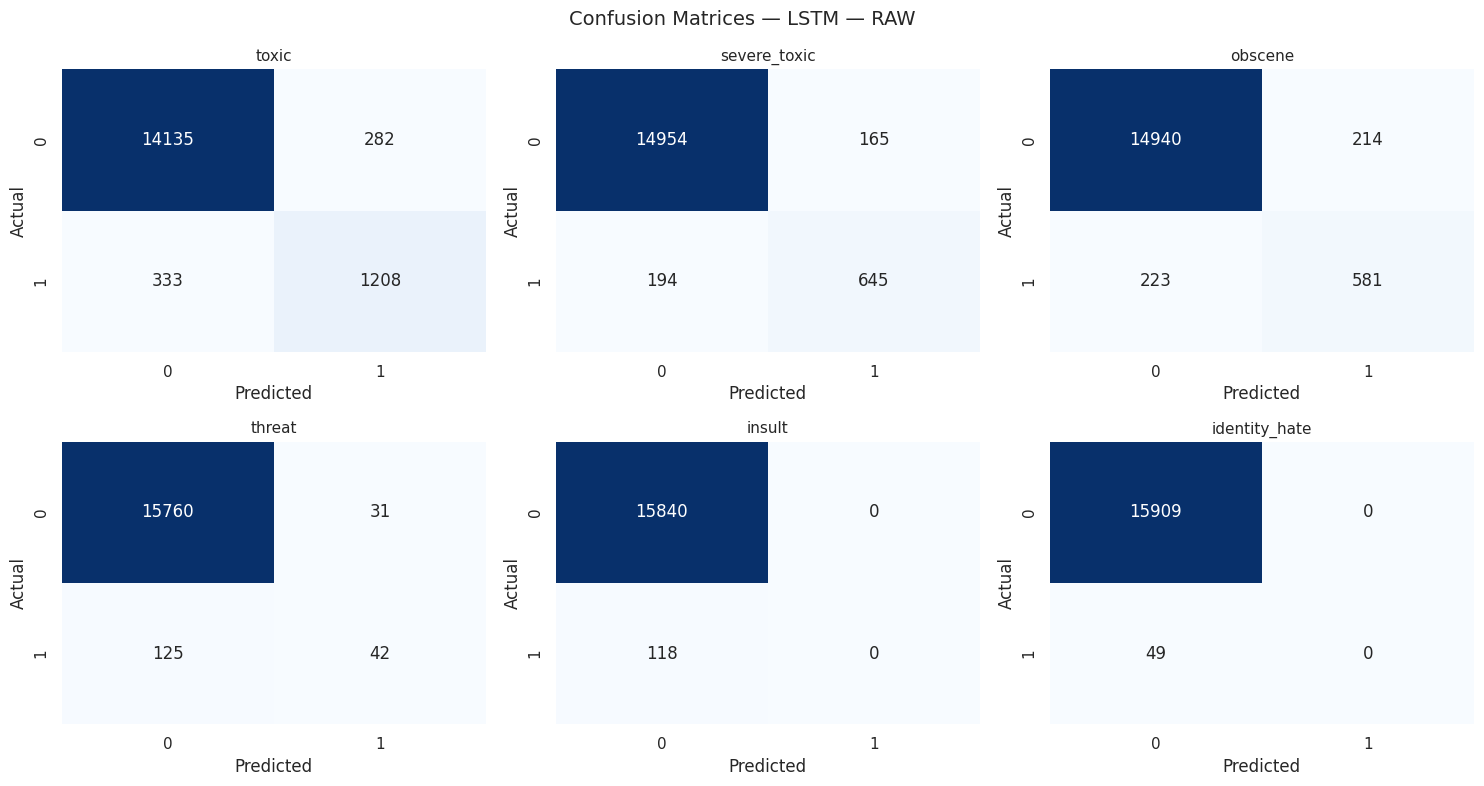

In [ ]:
plot_confusion('LSTM — RAW', y_test.values, y_pred_lstm_raw,label_cols)

Plot training curves

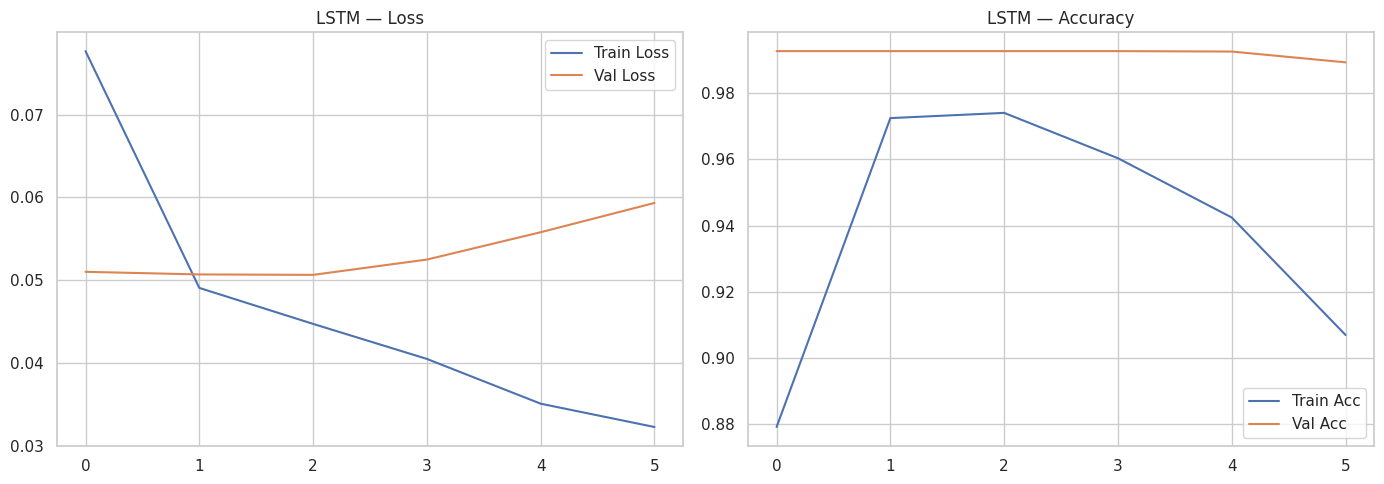

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM — Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('LSTM — Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 11. Transformer Model

##  BERT Fine-tuning

11.1 dataset class

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


class ToxicDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_len):

        self.texts = list(texts)
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.float
            )
        }


Device: cuda


In [ ]:
# Hyperparameters
BERT_BATCH = 16
BERT_EPOCHS = 4
BERT_MAX_LEN = 128
# Create datasets
train_ds = ToxicDataset(
    X_train["raw"],
    y_train.values,
    Bert_tokenizer,
    BERT_MAX_LEN
)

val_ds = ToxicDataset(
    X_val["raw"],
    y_val.values,
    Bert_tokenizer,
    BERT_MAX_LEN
)

test_ds = ToxicDataset(
    X_test["raw"],
    y_test.values,
    Bert_tokenizer,
    BERT_MAX_LEN
)
# DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=BERT_BATCH,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BERT_BATCH
)

test_loader = DataLoader(
    test_ds,
    batch_size=BERT_BATCH
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 7979
Val batches: 998


11.2 Load the model

In [ ]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)

bert_model.to(DEVICE)

optimizer = AdamW(
    bert_model.parameters(),
    lr=2e-5
)

criterion = torch.nn.BCEWithLogitsLoss()

total_steps = len(train_loader) * BERT_EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

[transformers] loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--distilbert-base-uncased/snapshots/12040accade4e8a0f71eabdb258fecc2e7e948be/config.json
[transformers] Model config DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "eos_token_id": null,
  "hidden_dim": 3072,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5"
  },
  "initializer_range": 0.02,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4,
    "LABEL_5": 5
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "problem_type": "multi_label_classification",
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "ti

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps = len(train_loader) * BERT_EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

criterion = torch.nn.BCEWithLogitsLoss()

print("BERT model ready.")

BERT model ready.


11.3 Training

In [ ]:
def run_epoch(model, loader, train=True):

    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0

    predictions = []
    labels_all = []

    for batch in loader:

        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()

        with torch.set_grad_enabled(train):

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            loss = criterion(logits, labels)

            if train:
                loss.backward()
                optimizer.step()
                scheduler.step()

        total_loss += loss.item()

        probs = torch.sigmoid(logits)

        predictions.extend(
            (probs > 0.5).cpu().numpy()
        )

        labels_all.extend(
            labels.cpu().numpy()
        )

    return (
        total_loss / len(loader),
        np.array(predictions),
        np.array(labels_all)
    )

11.3 training loop

In [ ]:
best_val_loss = float("inf")

start_train = time.time()

for epoch in range(BERT_EPOCHS):

    train_loss, _, _ = run_epoch(
        bert_model,
        train_loader,
        train=True
    )

    val_loss, val_pred, val_true = run_epoch(
        bert_model,
        val_loader,
        train=False
    )

    val_f1 = f1_score(
        val_true,
        val_pred,
        average="macro",
        zero_division=0
    )

    print(
        f"Epoch {epoch+1}/{BERT_EPOCHS}"
    )

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Val F1     : {val_f1:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            bert_model.state_dict(),
            "best_bert.pt"
        )

elapsed_train = time.time() - start_train

Epoch 1/4
Train Loss : 0.0474
Val Loss   : 0.0402
Val F1     : 0.6342
Epoch 2/4
Train Loss : 0.0327
Val Loss   : 0.0380
Val F1     : 0.6663
Epoch 3/4
Train Loss : 0.0248
Val Loss   : 0.0423
Val F1     : 0.6248
Epoch 4/4
Train Loss : 0.0185
Val Loss   : 0.0479
Val F1     : 0.6617


In [ ]:
bert_model.load_state_dict(torch.load("best_bert.pt"))

SAVE_PATH = "./saved_bert"

bert_model.save_pretrained(SAVE_PATH)
Bert_tokenizer.save_pretrained(SAVE_PATH)

print("Model and tokenizer saved successfully!")

[transformers] Configuration saved in ./saved_bert/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] Model weights saved in ./saved_bert/model.safetensors
[transformers] tokenizer config file saved in ./saved_bert/tokenizer_config.json


Model and tokenizer saved successfully!


#Only need to load it

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

SAVE_PATH = "./saved_bert"

Bert_tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
bert_model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH)

bert_model.to(DEVICE)
bert_model.eval()

[transformers] loading configuration file ./saved_bert/config.json
[transformers] Model config DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForSequenceClassification"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5"
  },
  "initializer_range": 0.02,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4,
    "LABEL_5": 5
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "problem_type": "multi_label_classification",
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.13.1",
  "

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
start = time.time()

_, y_pred_bert, y_true_bert = run_epoch(
    bert_model,
    test_loader,
    train=False
)

bert_infer_t = time.time() - start

11.4 evaluation

In [ ]:
bert_model.load_state_dict(
    torch.load("best_bert.pt")
)

bert_model.eval()

start = time.time()

test_loss, y_pred_bert, y_true_bert = run_epoch(
    bert_model,
    test_loader,
    train=False
)

bert_infer_t = time.time() - start

evaluate(
    "BERT — Raw",
    y_true_bert,
    y_pred_bert,
    elapsed_train,
    bert_infer_t
)

plot_confusion(
    "BERT — Raw",
    y_true_bert,
    y_pred_bert,
    label_cols
)

# 12. Comparative Analysis


## 12.1 performance comparison

In [ ]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1 (macro)']

results_df = pd.DataFrame.from_dict(results, orient='index').reset_index().rename(columns={'index': 'Model'})
plot_df = results_df[['Model'] + metric_cols].copy()
plot_df[metric_cols] = plot_df[metric_cols].astype(float)

plot_melted = plot_df.melt(id_vars='Model', value_vars=metric_cols,
                           var_name='Metric', value_name='Score')

display_name_map = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1 (macro)': 'F1 (macro)'
}
plot_melted['Metric'] = plot_melted['Metric'].map(display_name_map)


plt.figure(figsize=(14, 6))
sns.barplot(data=plot_melted, x='Metric', y='Score', hue='Model',
            palette='Set2')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12.2 preprocessing impact

In [ ]:
raw_models = [m for m in results if 'raw' in m.lower()]

clean_models = [
    m for m in results
    if 'clean' in m.lower() or 'advanced' in m.lower()
]

preprocess_rows = []
for arch in ['LR','SVM','LSTM']:
    raw_key   = next((m for m in raw_models   if arch.lower() in m.lower()), None)
    clean_key = next((m for m in clean_models if arch.lower() in m.lower()), None)
    if raw_key and clean_key:
        preprocess_rows.append({
            'Architecture': arch,
            'F1 Raw'      : results[raw_key]['f1 (macro)'],
            'F1 Cleaned'  : results[clean_key]['f1 (macro)']
        })

preproc_df = pd.DataFrame(preprocess_rows)

x = np.arange(len(preproc_df))
w = 0.35
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - w/2, preproc_df['F1 Raw'],     w, label='Raw Text',     color='#e74c3c')
ax.bar(x + w/2, preproc_df['F1 Cleaned'], w, label='Cleaned Text', color='#2ecc71')
ax.set_xticks(x); ax.set_xticklabels(preproc_df['Architecture'])
ax.set_title('Preprocessing Impact on F1 Score', fontsize=13)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig('preprocessing_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print(preproc_df)

## 12.3 training time

In [ ]:
time_df = results_df[['Model', 'train time (s)']].copy()
time_df = time_df[time_df['train time (s)'] != '-']
time_df['train time (s)'] = time_df['train time (s)'].astype(float)

plt.figure(figsize=(12, 5))
sns.barplot(data=time_df, x='Model', y='train time (s)', palette='Blues_d')
plt.title('Training Time Comparison (seconds)', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 12.4 error analysis

In [ ]:
test_texts = X_test['raw'].values

wrong_mask = (y_true_bert != y_pred_bert).any(axis=1)
wrong_idx  = np.where(wrong_mask)[0]

print(f'Misclassified samples (BERT): {wrong_mask.sum()} / {len(y_true_bert)}')

error_df = pd.DataFrame({
    'text'       : [test_texts[i][:200] for i in wrong_idx[:20]],
    'true_labels': [dict(zip(label_cols, y_true_bert[i])) for i in wrong_idx[:20]],
    'pred_labels': [dict(zip(label_cols, y_pred_bert[i])) for i in wrong_idx[:20]]
})

pd.set_option('display.max_colwidth', 120)
error_df.head(10)

#14. Final Discussion


In [ ]:
print('\n' + '='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)

print(results_df.to_string(index=False))

print('='*70)

# Pick highest F1
best_fast = results_df.loc[
    results_df['infer time (s)'].idxmin()
]
best_model = results_df.loc[
    results_df["f1 (macro)"].astype(float).idxmax()
]

print(f'\n🏆 Best model : {best_model["Model"]}')
print(f"\n⚡ Fastest model: {best_fast['Model']}")
print(f"🏆 Most accurate model: {best_model['Model']}")
print(f' F1 (macro) : {best_model["f1 (macro)"]:.4f}')
print(f' Accuracy   : {best_model["accuracy"]:.4f}')

Raw SVM

In [ ]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_tfidf_raw = tfidf_raw.transform(sample_comments)

pred_raw = svm_raw.predict(sample_tfidf_raw)

for text, pred in zip(sample_comments, pred_raw):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")

Advanced SVM

In [ ]:
sample_comments = [
    "I love your videos",
    "You are a stupid id#ot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [
    advanced_preprocess(t)
    for t in sample_comments
]

sample_tfidf_clean = tfidf_clean.transform(sample_clean)

pred_clean = svm_clean.predict(sample_tfidf_clean)

for text, pred in zip(sample_comments, pred_clean):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")

In [ ]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_seq_raw = lstm_tok_raw.texts_to_sequences(
    sample_comments
)

sample_pad_raw = pad_sequences(
    sample_seq_raw,
    maxlen=max_len,
    padding='post',
    truncating='post'
)


pred_probs_raw = lstm_raw_model.predict(sample_pad_raw)

pred_raw = (pred_probs_raw > 0.5).astype(int)

# display results
for text, pred in zip(sample_comments, pred_raw):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")

In [ ]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [
    advanced_preprocess(t)
    for t in sample_comments
]

sample_seq_clean = lstm_tok.texts_to_sequences(sample_clean)


sample_pad_clean = pad_sequences(
    sample_seq_clean,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

pred_probs_clean = lstm_model.predict(sample_pad_clean)

pred_clean = (pred_probs_clean > 0.5).astype(int)

for text, pred in zip(sample_comments, pred_clean):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):
        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")

Bert

In [ ]:

bert_model.load_state_dict(torch.load("best_bert.pt"))
bert_model.to(DEVICE)
bert_model.eval()


test_comments = [
    "I really love your work, keep it up!",
    "You are a stupid idiot",
    "Shut up moron",
    "bruh this is so dumb",
    "Wow great job ruining everything 👍",
    "I hate this so much 😡",
    "You are amazing 😂😂",
    "Not perfect, but still okay work",
    "The weather is nice today",
    "This is the worst explanation ever",
    "Kill yourself",
    "You are useless"
]


# Tokenize using SAME tokenizer as training
encodings = Bert_tokenizer(
    test_comments,
    truncation=True,
    padding='max_length',
    max_length=BERT_MAX_LEN,
    return_tensors='pt'
)

input_ids = encodings['input_ids'].to(DEVICE)
attention_mask = encodings['attention_mask'].to(DEVICE)


# Predict
with torch.no_grad():

    outputs = bert_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    probs = torch.sigmoid(outputs.logits)

    preds = (probs > 0.5).cpu().numpy()


# Show results + probabilities
for text, pred, prob in zip(test_comments, preds, probs.cpu().numpy()):

    print("\n" + "="*50)
    print("Comment:", text)

    toxic_found = False

    for label, p, value in zip(label_cols, prob, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic ({p:.3f})")

    if not toxic_found:
        print("Prediction: Non-toxic")

    print("Probabilities:")
    for label, p in zip(label_cols, prob):
        print(f" {label}: {p:.3f}")

In [ ]:
def compare_models():

    text = input("Enter comment: ")

    rows = []

    # ---------------- LR ----------------
    start = time.time()

    x = tfidf_clean.transform([advanced_preprocess(text)])
    pred = lr_clean.predict(x)[0]

    rows.append([
        "LR",
        ", ".join([l for l,v in zip(label_cols,pred) if v==1]) or "Non-toxic",
        results['TF-IDF + LR (advanced)']['accuracy'],
        results['TF-IDF + LR (advanced)']['f1 (macro)'],
        round(time.time()-start,3)
    ])


    # ---------------- SVM ----------------
    start = time.time()

    pred = svm_clean.predict(x)[0]

    rows.append([
        "SVM",
        ", ".join([l for l,v in zip(label_cols,pred) if v==1]) or "Non-toxic",
        results['TF-IDF + SVM (advanced)']['accuracy'],
        results['TF-IDF + SVM (advanced)']['f1 (macro)'],
        round(time.time()-start,3)
    ])


    # ---------------- BiLSTM ----------------
    start = time.time()

    seq = lstm_tok.texts_to_sequences(
        [advanced_preprocess(text)]
    )

    pad = pad_sequences(seq,maxlen=max_len)

    pred = (
        lstm_model.predict(
            pad,
            verbose=0
        ) > 0.5
    ).astype(int)[0]

    rows.append([
        "BiLSTM",
        ", ".join([l for l,v in zip(label_cols,pred) if v==1]) or "Non-toxic",
        results['LSTM — advanced_clean']['accuracy'],
        results['LSTM — advanced_clean']['f1 (macro)'],
        round(time.time()-start,3)
    ])


    # ---------------- BERT ----------------
    start = time.time()

    enc = Bert_tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=BERT_MAX_LEN
    )

    with torch.no_grad():

        out = bert_model(
            input_ids=enc['input_ids'].to(DEVICE),
            attention_mask=enc['attention_mask'].to(DEVICE)
        )

    pred = (
        torch.sigmoid(out.logits)>0.5
    ).cpu().numpy()[0]

    rows.append([
        "BERT",
        ", ".join([l for l,v in zip(label_cols,pred) if v==1]) or "Non-toxic",
        results['BERT — Raw']['accuracy'],
        results['BERT — Raw']['f1 (macro)'],
        round(time.time()-start,3)
    ])



    df = pd.DataFrame(
        rows,
        columns=[
            "Model",
            "Prediction",
            "Accuracy",
            "F1",
            "Inference Time(s)"
        ]
    )

    print("\nInput:")
    print(text)
    print()

    display(df)

    # ---------- Best model ----------
    best = df.loc[df["F1"].idxmax()]

    print(
        f"\n🏆 Best Model Overall: "
        f"{best['Model']} "
        f"(F1={best['F1']}, "
        f"Accuracy={best['Accuracy']})"
    )

In [ ]:
compare_models()

# UI